#### **Backpropagation in CNN**

**Backpropagation** is the process used to train a Convolutional Neural Network (CNN). It calculates **how much each weight contributed to the error** and then updates those weights to make the CNN better. A simple way to remember it:

> **Forward propagation → Calculate loss → Backpropagation → Update weights → Repeat**

---

#### **CNN Training Overview**

A CNN typically works like this:

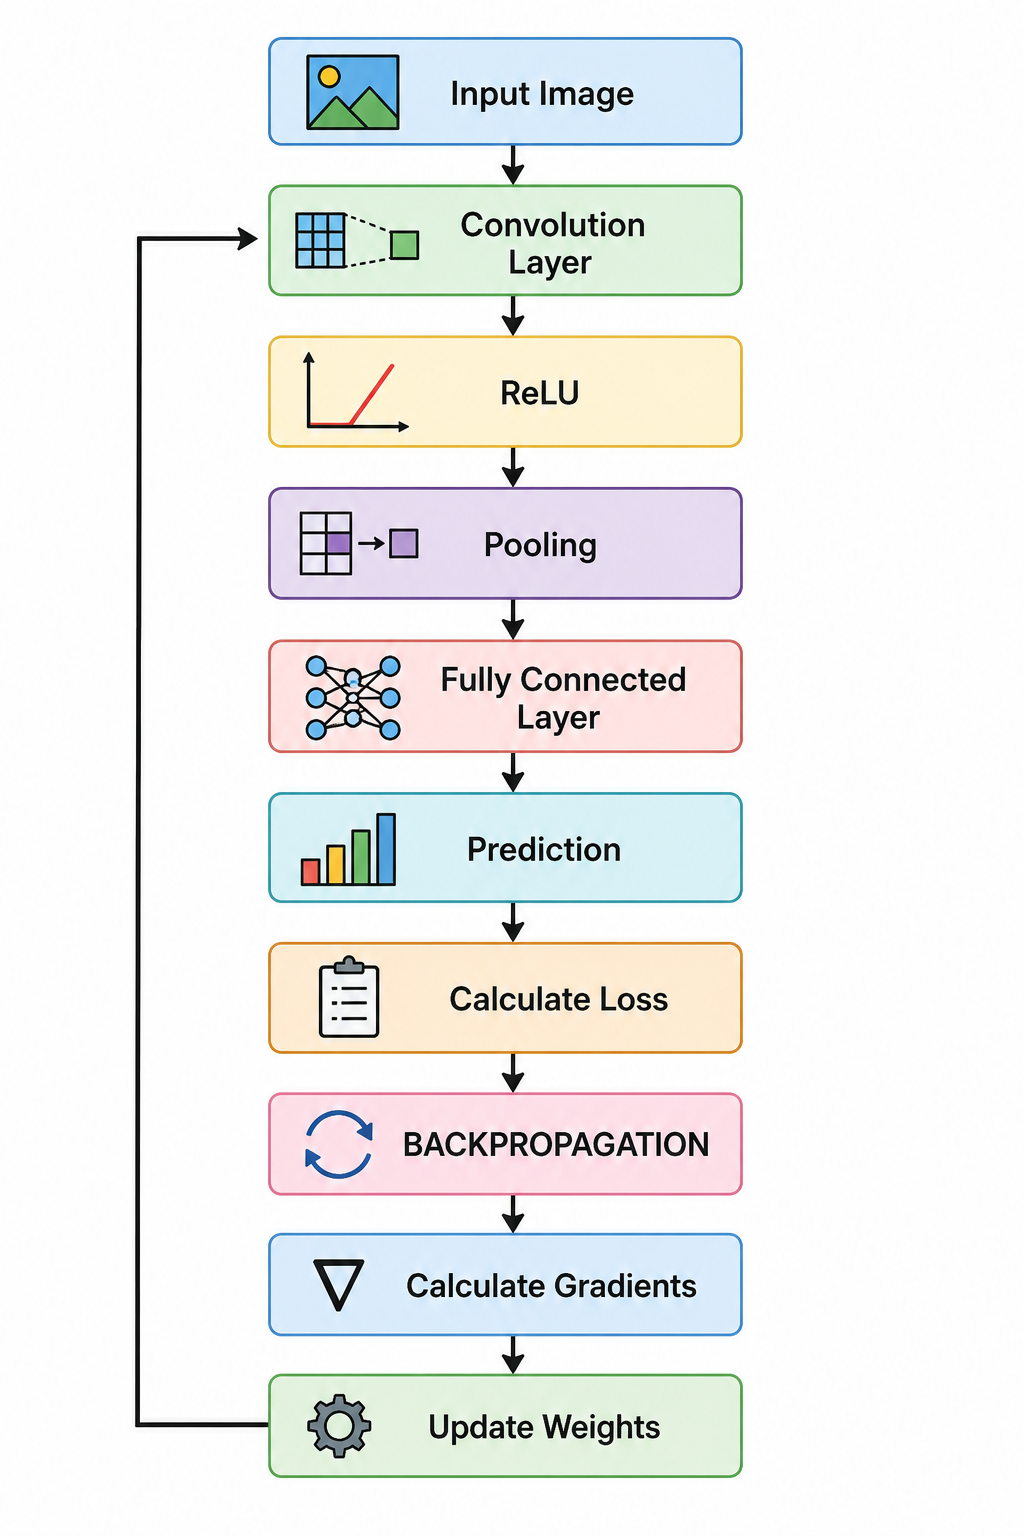

The important point is that **backpropagation travels backward through every layer**.

---

#### **What Is the Goal?**

Suppose we give a CNN an image of a cat. The correct answer is `Cat = 1 and Dog = 0`. But the CNN predicts `Cat = 0.30 and Dog = 0.70`. The prediction is wrong, so we calculate a **loss**.

```text
Prediction ──────────┐
                     ▼
                 Loss Function
                     ▲
Actual Label ────────┘
```

The loss tells us **How wrong was the prediction?**

---

#### **Forward Propagation**

Before backpropagation happens, the CNN performs **forward propagation**. For example:

```text
Image
  ▼
Convolution
  ▼
Feature Map
  ▼
ReLU
  ▼
Pooling
  ▼
Fully Connected
  ▼
Prediction
```

Each layer performs some mathematical operation. Eventually we get `Prediction = 0.30`. Then we calculate the loss.

---

#### **Backpropagation**

Now the CNN asks **Which weights caused this error and by how much?** It starts from the loss and moves **backward**.

```text
Loss
 ▼
Fully Connected Layer
 ▼
Pooling Layer
 ▼
ReLU
 ▼
Convolution Layer
 ▼
Kernel Weights
```

At each layer, we calculate **gradients**. A gradient tells us how much the loss changes when a particular parameter changes. Mathematically:

$$
\frac{\partial L}{\partial W}
$$

where:

* $L$ = Loss
* $W$ = Weight
* $\frac{\partial L}{\partial W}\$ = Gradient of the loss with respect to the weight

---

#### **Why Do We Need Gradients?**

Suppose a convolution kernel contains:

```text
┌──────────┐
│ 0.2  0.5 │
│ 0.1  0.4 │
└──────────┘
```

After backpropagation, we might obtain:

```text
Gradient:
┌─────────────-┐
│  0.10  -0.20 │
│  0.05   0.15 │
└─────────────-┘
```

These gradients tell us the direction in which the weights should change.

---

#### **Weight Update**

Once gradients are calculated, the optimizer updates the weights. The basic gradient descent equation is:

$$
W_{new}=W_{old}-\eta\frac{\partial L}{\partial W}
$$

where:

* $W_{old}$ = current weight
* $W_{new}$ = updated weight
* $\eta$ = learning rate
* $\frac{\partial L}{\partial W}$ = gradient

For example:

```text
Old weight = 0.50
Gradient   = 0.20
Learning rate = 0.01
```

Then:

$$
W_{new}=0.50-(0.01)(0.20)
$$

$$
W_{new}=0.498
$$

So `Before: 0.500  After:  0.498`

---

#### **Backpropagation Through a CNN**

This is the most important part. Suppose our CNN is:

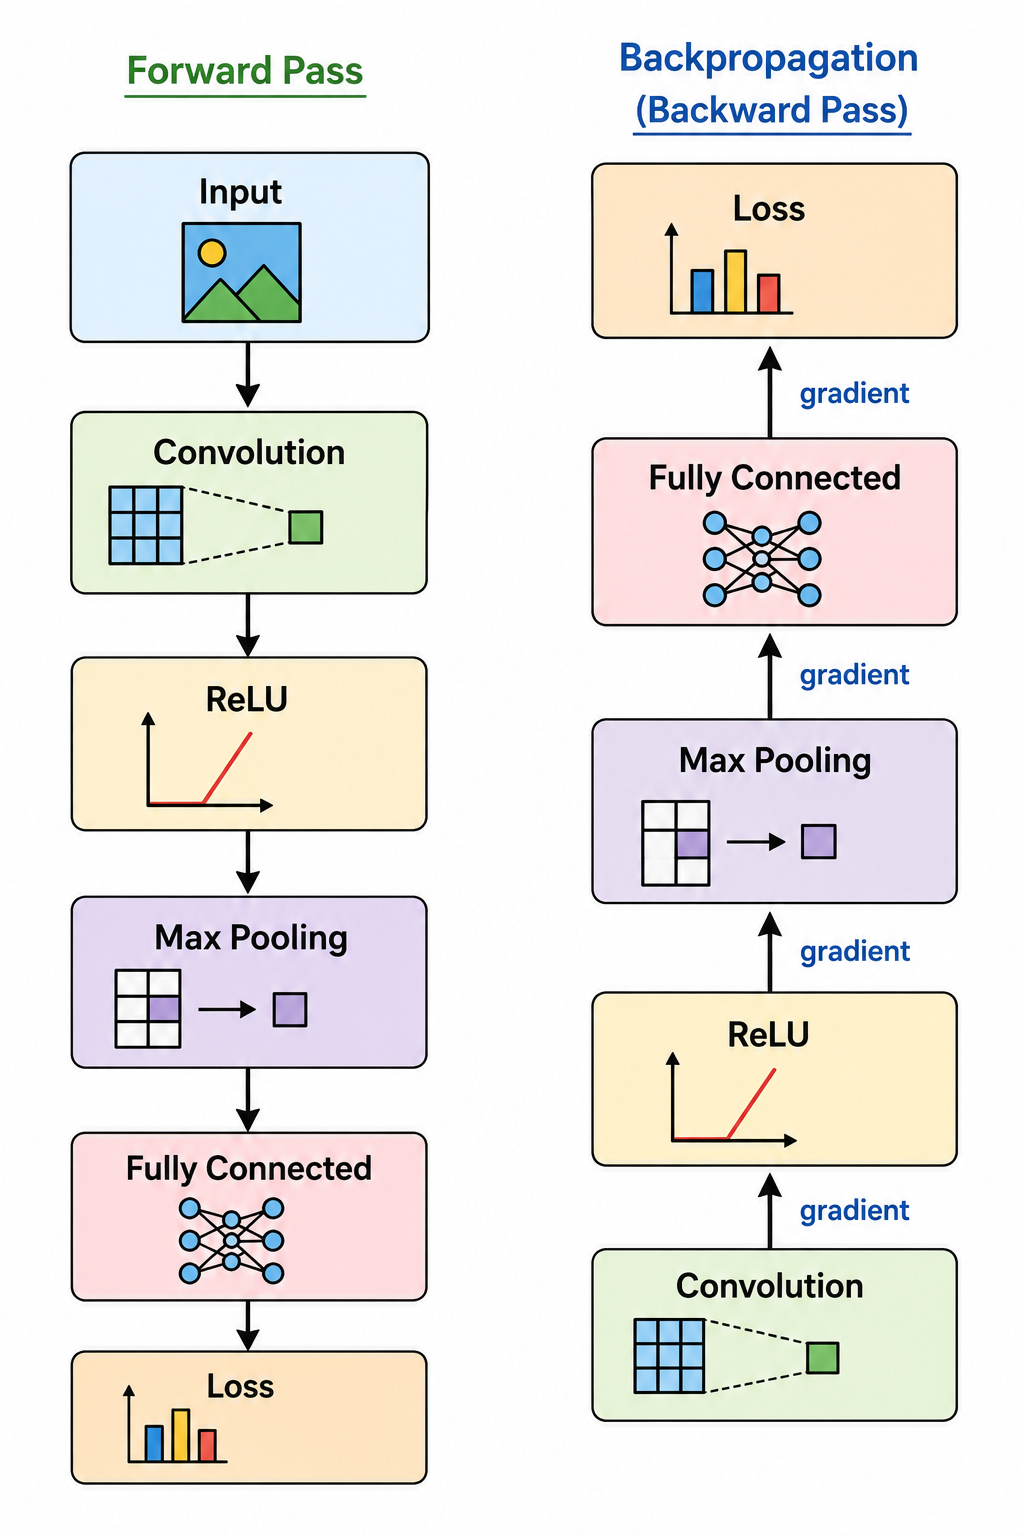

Each layer applies the **chain rule** to calculate gradients.

---

#### **Chain Rule**

Backpropagation is essentially an efficient application of the **chain rule of calculus**. Suppose: $x \rightarrow y \rightarrow z \rightarrow L$. Then:

$$
\frac{\partial L}{\partial x}=
\frac{\partial L}{\partial z}
\frac{\partial z}{\partial y}
\frac{\partial y}{\partial x}
$$

This allows the CNN to calculate how an early parameter affects the final loss.

---

#### **Backpropagation Through Convolution** 

This is particularly important in CNNs. Suppose:

```text
Input:
┌───┬───┬───┐
│ 1 │ 2 │ 3 │
├───┼───┼───┤
│ 4 │ 5 │ 6 │
├───┼───┼───┤
│ 7 │ 8 │ 9 │
└───┴───┴───┘
```

and the kernel is:

```text
┌───┬───┐
│ a │ b │
├───┼───┤
│ c │ d │
└───┴───┘
```

The convolution produces an output. During backpropagation, the CNN calculates:

```text
∂Loss/∂a
∂Loss/∂b
∂Loss/∂c
∂Loss/∂d
```

So the kernel learns which values are useful for detecting features.

---

#### **Backpropagation Through ReLU** 

ReLU is: $ReLU(x)=\max(0,x)$. Its derivative is:

$$
ReLU'(x)=
\begin{cases}
1 & x>0\\
0 & x\leq0
\end{cases}
$$

Therefore:

```text
Forward:
-2 → ReLU → 0
 3 → ReLU → 3
```

During backpropagation:

```text
-2 → gradient becomes 0
 3 → gradient passes through
```

So ReLU controls which gradients are allowed to flow backward.

---

#### **Backpropagation Through Max Pooling**

Suppose we have:

```text
┌───┬───┐
│ 1 │ 5 │
├───┼───┤
│ 2 │ 3 │
└───┴───┘
```

Max pooling gives `5`. During backpropagation, the gradient goes to the position that contained the maximum value:

```text
┌───┬───┐
│ 0 │ G │
├───┼───┤
│ 0 │ 0 │
└───┴───┘
```

where `G` is the incoming gradient.

---

#### **Backpropagation Through Fully Connected Layer**

Suppose:

```text
Feature Vector
      ▼
Fully Connected
      ▼
Prediction
      ▼
    Loss
```

The gradient flows backward:

```text
Loss-> Output weights-> Input features
```

The fully connected layer's weights are also updated.

---

#### **Backpropagation vs Gradient Descent**

These two are related but **not the same thing**.

**Backpropagation:** Calculates the gradients:

$$
\frac{\partial L}{\partial W}
$$

**Gradient Descent / Optimizer:** Uses those gradients to update the parameters:

$$
W=W-\eta\frac{\partial L}{\partial W}
$$

So:

```text
Backpropagation-> Calculates gradients-> Optimizer-> Updates weights
```

In PyTorch, this distinction is very visible `loss.backward()` performs **backpropagation** and calculates gradients. Then `optimizer.step()` uses those gradients to **update the weights**.

#### **Implementation of CNN Backpropagation in PyTorch**

Let's implement **CNN backpropagation from scratch using PyTorch** so you can clearly see what happens during training.

We'll use **MNIST** where the CNN learns to recognize handwritten digits `0–9`.

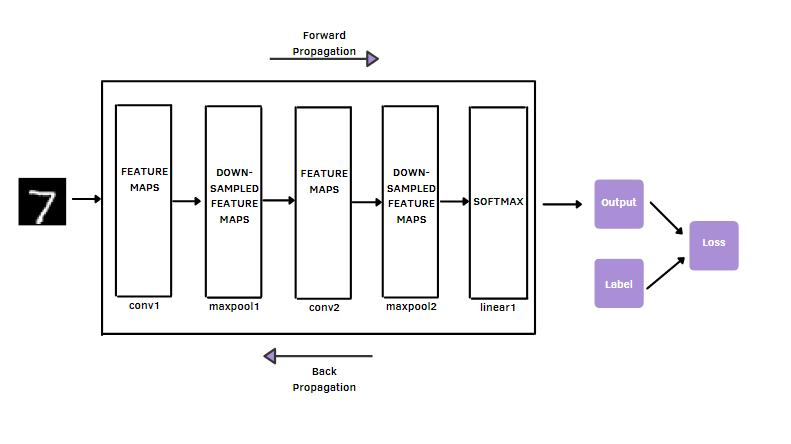

#### **Import Libraries**

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

---

#### **Load the MNIST Dataset**

In [3]:
transform = transforms.ToTensor()

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

100%|██████████████████████████████████████████████████████████████████████████████| 9.91M/9.91M [00:11<00:00, 877kB/s]
100%|██████████████████████████████████████████████████████████████████████████████| 28.9k/28.9k [00:00<00:00, 100kB/s]
100%|██████████████████████████████████████████████████████████████████████████████| 1.65M/1.65M [00:01<00:00, 906kB/s]
100%|█████████████████████████████████████████████████████████████████████████████| 4.54k/4.54k [00:00<00:00, 3.85MB/s]


#### **Create the CNN**

In [4]:
class CNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(
            in_channels = 1,
            out_channels = 16,
            kernel_size = 3,
            padding = 1
        )

        self.relu = nn.ReLU()

        self.pool = nn.MaxPool2d(
            kernel_size = 2,
            stride = 2
        )

        self.conv2 = nn.Conv2d(
            in_channels = 16, 
            out_channels = 32,
            kernel_size = 3,
            padding = 1
        )

        self.fc = nn.Linear(
            32*7*7,
            10
        )

    def forward(self, x):
        x = self.conv1(x)
        x = self.relu(x)
        x = self.pool(x)

        x = self.conv2(x)
        x = self.relu(x)
        x = self.pool(x)

        x = x.view(x.size(0), -1)
        x = self.fc(x)

        return x

# Create the model
model = CNN()
print(model)

CNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu): ReLU()
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc): Linear(in_features=1568, out_features=10, bias=True)
)


---

#### **Understand the Forward Pass**

For a `28 × 28` image:

```text
Input: 28 × 28 × 1
     ▼
Conv1: 28 × 28 × 16
     ▼
ReLU: 28 × 28 × 16
     ▼
MaxPool: 14 × 14 × 16
     ▼
Conv2: 14 × 14 × 32
     ▼
ReLU: 14 × 14 × 32
     ▼
MaxPool: 7 × 7 × 32
     ▼
Flatten: 1568
     ▼
Fully Connected: 10
     ▼
Prediction
```

Notice $32\times7\times7=1568$. That's why we use:

```python
nn.Linear(32 * 7 * 7, 10)
```

---

#### **Loss Function and Optimizer**

In [6]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(
    model.parameters(),
    lr = 0.001
)

The loss tells us **how wrong the prediction is**. The optimizer determines **how the weights should be changed**.

---

#### **CNN Backpropagation**

In [ ]:
for images, labels in train_loader:
    # Forward pass
    outputs = model(images)

    # Calculate loss
    loss = criterion(outputs, labels)

    # Clear gradients
    optimizer.zero_grad()

    # Backpropagation
    loss.backward()

    # Update weights
    optimizer.step()

# Gradients
# print(model.conv1.weight.grad)
# print(model.conv2.weight.grad)
# print(model.fc.weight.grad)

---

#### **Inspect the Gradient**

Let's make one training step and inspect the gradient.

In [14]:
images, labels = next(iter(train_loader))

# Forward pass
outputs = model(images)

# Loss
loss = criterion(outputs, labels)

# Clear old gradients
optimizer.zero_grad()

# Backpropagation
loss.backward()

print("Loss:", loss.item())
print("Gradient shape:", model.conv1.weight.grad.shape)

Loss: 0.023423854261636734
Gradient shape: torch.Size([16, 1, 3, 3])


#### **Test the CNN**

In [15]:
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)

        correct += (
            predicted == labels
        ).sum().item()


accuracy = 100 * correct / total
print(f"Accuracy: {accuracy:.2f}%")

Accuracy: 98.59%
